# 12 — Auditoria da Nova Referência 24h/8h

## Objetivo

Auditar falsos positivos e falsos negativos da nova referência técnica:

> gap 900s, observação 24h, horizonte 8h, Random Forest com IDs + conceitos textuais.

Comparação principal:

- baseline histórico: gap 60s, observação 8h, horizonte 8h, `RF_ids`;
- nova referência: gap 900s, observação 24h, horizonte 8h, `RF_ids_textual`.

## Limites

- `Is_Dont_Go` continua sendo target provisório, não falha confirmada;
- os resultados com buckets de 8h servem para comparar cenários de desenvolvimento;
- o teste não participa da seleção de threshold;
- a auditoria orienta próximos experimentos, não produção.

In [1]:
from pathlib import Path
import re
import time
import unicodedata

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score, fbeta_score,
    precision_score, recall_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

TOP_ALARM_IDS = 200
TOP_TEXT_CONCEPTS = 200
LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)
MISSING_START = pd.Timestamp("2025-05-31 00:00:00")
MISSING_END = pd.Timestamp("2025-06-01 00:00:00")

SCENARIOS = [
    {
        "cenario": "baseline_60s_8h8h_ids",
        "gap_s": 60,
        "observacao_h": 8,
        "horizonte_h": 8,
        "use_text_concepts": False,
    },
    {
        "cenario": "referencia_900s_24h8h_ids_textual",
        "gap_s": 900,
        "observacao_h": 24,
        "horizonte_h": 8,
        "use_text_concepts": True,
    },
]

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

def normalize_alarm_name(value):
    if pd.isna(value):
        return "SEM_DESCRICAO"
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s*\(L-?\d+\)\s*$", "", text)
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or "SEM_DESCRICAO"

def is_excavator(series):
    return series.fillna("").str.contains("ESCAV", case=False, regex=True)

print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: /home/f_szekut/projects/vale_correct


## 1. Camada analítica congelada

In [2]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

base_audit = query(
    '''
    SELECT
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo - 1) AS duplicatas_retiradas,
        sum(Is_Dont_Go) AS linhas_dont_go
    FROM analytic_events
    '''
)
base_audit["tempo_s"] = round(time.time() - start, 1)
display(base_audit)

,registros_analiticos,duplicatas_retiradas,linhas_dont_go,tempo_s
0,35608094,265564.0,19941.0,16.1


## 2. Funções

In [3]:
def build_sequences(gap_s):
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_sequences AS
        WITH ordered AS (
            SELECT *,
                   lag(Data_Evento) OVER (
                       PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ) AS evento_anterior
            FROM analytic_events
        ), flagged AS (
            SELECT *,
                   CASE
                       WHEN evento_anterior IS NULL THEN 1
                       WHEN date_diff('millisecond', evento_anterior, Data_Evento) > {gap_s * 1000} THEN 1
                       ELSE 0
                   END AS nova_sequencia
            FROM ordered
        ), numbered AS (
            SELECT *,
                   sum(nova_sequencia) OVER (
                       PARTITION BY TAG, Id_Alarme
                       ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                       ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                   ) AS numero_sequencia
            FROM flagged
        )
        SELECT
            TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
            Id_Alarme, any_value(Alarme) AS Alarme,
            numero_sequencia,
            min(Data_Evento) AS inicio,
            max(Data_Evento) AS fim,
            time_bucket(INTERVAL '8 hours', min(Data_Evento)) AS bin_start,
            date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
            count(*) AS registros_analiticos,
            sum(ids_evento_no_grupo) AS registros_brutos_representados,
            max(Is_Dont_Go) AS is_dont_go,
            max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
            max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
            max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
            max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
        FROM numbered
        GROUP BY TAG, Id_Alarme, numero_sequencia
        '''
    )
    return query(
        '''
        SELECT
            count(*) AS sequencias,
            sum(is_dont_go) AS sequencias_dont_go,
            avg(registros_analiticos) AS registros_por_sequencia_media,
            max(registros_analiticos) AS maior_sequencia
        FROM alarm_sequences
        '''
    )

def create_catalog():
    catalog = query(
        '''
        SELECT Id_Alarme, any_value(Alarme) AS Alarme, count(*) AS sequencias
        FROM alarm_sequences
        GROUP BY 1
        ORDER BY sequencias DESC
        '''
    )
    catalog["conceito_textual"] = catalog["Alarme"].map(normalize_alarm_name)
    con.register("alarm_concepts", catalog[["Id_Alarme", "conceito_textual"]])
    return catalog

def build_sample_grid(observation_h, horizon_h):
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE sample_grid AS
        WITH tags AS (
            SELECT DISTINCT TAG FROM analytic_events
        ), prediction_bins AS (
            SELECT * FROM generate_series(
                TIMESTAMP '2025-01-01 00:00:00' + INTERVAL '{observation_h} hours',
                TIMESTAMP '2025-07-01 00:00:00' - INTERVAL '{horizon_h} hours',
                INTERVAL '8 hours'
            ) AS t(prediction_time)
        )
        SELECT
            row_number() OVER () AS sample_id,
            tags.TAG,
            prediction_time - INTERVAL '{observation_h} hours' AS feature_start,
            prediction_time,
            prediction_time + INTERVAL '{horizon_h} hours' AS target_end
        FROM tags CROSS JOIN prediction_bins
        WHERE prediction_time - INTERVAL '{observation_h} hours' >= TIMESTAMP '2025-01-01 00:00:00'
        '''
    )

def build_bins():
    con.execute(
        '''
        CREATE OR REPLACE TEMP TABLE sequence_bins AS
        SELECT
            TAG, bin_start,
            count(*) AS sequencias_total,
            count(DISTINCT Id_Alarme) AS alarmes_distintos,
            sum(registros_analiticos) AS registros_analiticos,
            sum(registros_brutos_representados) AS registros_brutos_representados,
            sum(duracao_ms) AS duracao_soma_ms,
            max(duracao_ms) AS duracao_max_ms,
            max(registros_analiticos) AS maior_sequencia_registros,
            sum(possui_critico) AS sequencias_com_critico,
            sum(possui_activate) AS sequencias_com_activate,
            sum(possui_inactive) AS sequencias_com_inactive,
            sum(possui_classe_nula) AS sequencias_com_classe_nula,
            sum(is_dont_go) AS episodios_dont_go
        FROM alarm_sequences
        GROUP BY 1, 2
        '''
    )

def build_samples():
    samples = query(
        f'''
        WITH feature_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(b.sequencias_total), 0) AS sequencias_total,
                coalesce(sum(b.alarmes_distintos), 0) AS alarmes_distintos,
                coalesce(sum(b.registros_analiticos), 0) AS registros_analiticos,
                coalesce(sum(b.registros_brutos_representados), 0) AS registros_brutos_representados,
                CASE
                    WHEN coalesce(sum(b.sequencias_total), 0) > 0
                    THEN coalesce(sum(b.duracao_soma_ms), 0) / sum(b.sequencias_total)
                    ELSE 0
                END AS duracao_media_ms,
                coalesce(max(b.duracao_max_ms), 0) AS duracao_max_ms,
                coalesce(max(b.maior_sequencia_registros), 0) AS maior_sequencia_registros,
                coalesce(sum(b.sequencias_com_critico), 0) AS sequencias_com_critico,
                coalesce(sum(b.sequencias_com_activate), 0) AS sequencias_com_activate,
                coalesce(sum(b.sequencias_com_inactive), 0) AS sequencias_com_inactive,
                coalesce(sum(b.sequencias_com_classe_nula), 0) AS sequencias_com_classe_nula
            FROM sample_grid g
            LEFT JOIN sequence_bins b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.feature_start
             AND b.bin_start < g.prediction_time
            GROUP BY 1
        ), target_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(b.episodios_dont_go), 0) AS episodios_dont_go_target
            FROM sample_grid g
            LEFT JOIN sequence_bins b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.prediction_time
             AND b.bin_start < g.target_end
            GROUP BY 1
        )
        SELECT
            g.TAG, g.feature_start, g.prediction_time, g.target_end,
            f.* EXCLUDE(sample_id),
            y.episodios_dont_go_target,
            CASE WHEN y.episodios_dont_go_target > 0 THEN 1 ELSE 0 END AS target,
            CASE
                WHEN g.feature_start < TIMESTAMP '{MISSING_END}'
                 AND g.target_end > TIMESTAMP '{MISSING_START}'
                THEN 0 ELSE 1
            END AS amostra_valida
        FROM sample_grid g
        JOIN feature_agg f USING(sample_id)
        JOIN target_agg y USING(sample_id)
        ORDER BY g.prediction_time, g.TAG
        '''
    )
    samples = samples[samples["amostra_valida"] == 1].copy()
    tag_profile = query(
        '''
        SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
        FROM analytic_events
        GROUP BY 1
        '''
    )
    samples = samples.merge(tag_profile, how="left", on="TAG")
    samples = samples.assign(split=np.select(
        [
            samples["prediction_time"] < pd.Timestamp("2025-05-01"),
            samples["prediction_time"] < pd.Timestamp("2025-05-31"),
            samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
        ],
        ["treino", "validacao", "teste"],
        default="fora_do_split",
    ))
    return samples[samples["split"].isin(["treino", "validacao", "teste"])].copy()

In [4]:
def add_id_features(samples):
    top_ids = query(
        f'''
        SELECT Id_Alarme, count(*) AS sequencias
        FROM alarm_sequences
        WHERE inicio < TIMESTAMP '2025-05-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, Id_Alarme
        LIMIT {TOP_ALARM_IDS}
        '''
    )["Id_Alarme"].astype(int).tolist()
    expr = ",\n".join(
        f"sum(CASE WHEN Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
        for alarm_id in top_ids
    )
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_bin_features AS
        SELECT TAG, bin_start, {expr}
        FROM alarm_sequences
        GROUP BY 1, 2
        '''
    )
    sum_expr = ", ".join(
        f"coalesce(sum(b.alarm_{alarm_id}), 0) AS alarm_{alarm_id}" for alarm_id in top_ids
    )
    wide = query(
        f'''
        SELECT g.TAG, g.feature_start, {sum_expr}
        FROM sample_grid g
        LEFT JOIN alarm_bin_features b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1, 2
        '''
    )
    features = [f"alarm_{alarm_id}" for alarm_id in top_ids]
    samples = samples.merge(wide, how="left", on=["TAG", "feature_start"])
    samples[features] = samples[features].fillna(0).astype("int32")
    return samples, features

def add_text_features(samples):
    top = query(
        f'''
        SELECT c.conceito_textual AS valor, count(*) AS sequencias
        FROM alarm_sequences s
        JOIN alarm_concepts c USING(Id_Alarme)
        WHERE s.inicio < TIMESTAMP '2025-05-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, valor
        LIMIT {TOP_TEXT_CONCEPTS}
        '''
    )
    values = top["valor"].tolist()
    name_map = {value: f"textconcept_{i:03d}" for i, value in enumerate(values)}
    def lit(value):
        return "'" + str(value).replace("'", "''") + "'"
    expr = ",\n".join(
        f"sum(CASE WHEN c.conceito_textual = {lit(value)} THEN 1 ELSE 0 END) AS {name_map[value]}"
        for value in values
    )
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE text_bin_features AS
        SELECT s.TAG, s.bin_start, {expr}
        FROM alarm_sequences s
        LEFT JOIN alarm_concepts c USING(Id_Alarme)
        GROUP BY 1, 2
        '''
    )
    sum_expr = ", ".join(
        f"coalesce(sum(b.{name_map[value]}), 0) AS {name_map[value]}" for value in values
    )
    wide = query(
        f'''
        SELECT g.TAG, g.feature_start, {sum_expr}
        FROM sample_grid g
        LEFT JOIN text_bin_features b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1, 2
        '''
    )
    features = [name_map[value] for value in values]
    samples = samples.merge(wide, how="left", on=["TAG", "feature_start"])
    samples[features] = samples[features].fillna(0).astype("int32")
    return samples, features

def add_base_features(samples):
    samples = pd.concat([
        samples,
        pd.DataFrame({
            "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
            "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
            "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
        }, index=samples.index)
    ], axis=1).copy()
    base = [
        "sequencias_total", "alarmes_distintos", "registros_analiticos",
        "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
        "maior_sequencia_registros", "sequencias_com_critico",
        "sequencias_com_activate", "sequencias_com_inactive",
        "sequencias_com_classe_nula", "feature_has_events",
        "prediction_hour_sin", "prediction_hour_cos",
        "prediction_dow_sin", "prediction_dow_cos",
    ]
    return samples, base

In [5]:
def select_threshold(y_true, probability):
    rows = []
    for threshold in np.linspace(0.01, 0.99, 197):
        pred = probability >= threshold
        rows.append({
            "threshold": threshold,
            "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
        })
    scores = pd.DataFrame(rows)
    best = scores.sort_values(["f2", "precision", "threshold"], ascending=[False, False, False]).iloc[0]
    return float(best["threshold"])

def metric_row(cenario, split, y_true, prob, threshold, extra):
    pred = (prob >= threshold).astype(int)
    row = {
        "cenario": cenario,
        "split": split,
        "threshold": threshold,
        "amostras": len(y_true),
        "positivas": int(y_true.sum()),
        "pr_auc": average_precision_score(y_true, prob),
        "roc_auc": roc_auc_score(y_true, prob),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "predicoes_positivas": int(pred.sum()),
        "TP": int(((y_true == 1) & (pred == 1)).sum()),
        "FP": int(((y_true == 0) & (pred == 1)).sum()),
        "FN": int(((y_true == 1) & (pred == 0)).sum()),
        "TN": int(((y_true == 0) & (pred == 0)).sum()),
    }
    row.update(extra)
    return row

def fit_model(samples, features, cenario, extra):
    train = samples[samples["split"] == "treino"]
    val = samples[samples["split"] == "validacao"]
    test = samples[samples["split"] == "teste"]
    model = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(train[features].astype("float32"), train["target"].astype("int8"))
    val_prob = model.predict_proba(val[features].astype("float32"))[:, 1]
    threshold = select_threshold(val["target"].astype("int8"), val_prob)
    test_prob = model.predict_proba(test[features].astype("float32"))[:, 1]
    metrics = pd.DataFrame([
        metric_row(cenario, "validacao", val["target"].astype("int8"), val_prob, threshold, extra),
        metric_row(cenario, "teste", test["target"].astype("int8"), test_prob, threshold, extra),
    ])
    pred = test[["TAG", "Tipo", "Tag_Frota", "feature_start", "prediction_time", "target_end", "target"]].copy()
    pred["cenario"] = cenario
    pred["probabilidade"] = test_prob
    pred["predito"] = (test_prob >= threshold).astype("int8")
    pred["erro"] = np.select(
        [
            (pred["target"] == 1) & (pred["predito"] == 1),
            (pred["target"] == 0) & (pred["predito"] == 1),
            (pred["target"] == 1) & (pred["predito"] == 0),
            (pred["target"] == 0) & (pred["predito"] == 0),
        ],
        ["TP", "FP", "FN", "TN"],
        default="indefinido",
    )
    return metrics, pred

def summarize_group(df, group_cols):
    out = (
        df.assign(
            TP=(df["erro"] == "TP").astype(int),
            FP=(df["erro"] == "FP").astype(int),
            FN=(df["erro"] == "FN").astype(int),
            TN=(df["erro"] == "TN").astype(int),
        )
        .groupby(group_cols, dropna=False)
        .agg(
            amostras=("target", "size"),
            positivos_reais=("target", "sum"),
            positivos_previstos=("predito", "sum"),
            TP=("TP", "sum"),
            FP=("FP", "sum"),
            FN=("FN", "sum"),
            TN=("TN", "sum"),
            prob_media=("probabilidade", "mean"),
            prob_p90=("probabilidade", lambda x: x.quantile(.90)),
        )
        .reset_index()
    )
    out["precision"] = out["TP"] / (out["TP"] + out["FP"]).replace(0, np.nan)
    out["recall"] = out["TP"] / (out["TP"] + out["FN"]).replace(0, np.nan)
    out["taxa_fp"] = out["FP"] / (out["FP"] + out["TN"]).replace(0, np.nan)
    out["prevalencia"] = out["positivos_reais"] / out["amostras"]
    return out

## 3. Treino dos cenários

In [6]:
all_metrics = []
all_predictions = []
scenario_audits = []

for cfg in SCENARIOS:
    print(f"Executando {cfg['cenario']}")
    start = time.time()
    seq_audit = build_sequences(cfg["gap_s"])
    create_catalog()
    build_sample_grid(cfg["observacao_h"], cfg["horizonte_h"])
    build_bins()
    samples = build_samples()
    samples, base_features = add_base_features(samples)
    samples, id_features = add_id_features(samples)
    feature_columns = base_features + id_features
    if cfg["use_text_concepts"]:
        samples, text_features = add_text_features(samples)
        feature_columns = feature_columns + text_features
    metrics, pred = fit_model(
        samples,
        feature_columns,
        cfg["cenario"],
        {
            "gap_s": cfg["gap_s"],
            "observacao_h": cfg["observacao_h"],
            "horizonte_h": cfg["horizonte_h"],
            "features": len(feature_columns),
            "sequencias": int(seq_audit.loc[0, "sequencias"]),
            "sequencias_dont_go": int(seq_audit.loc[0, "sequencias_dont_go"]),
        },
    )
    metrics["tempo_s"] = round(time.time() - start, 1)
    all_metrics.append(metrics)
    all_predictions.append(pred)
    split_audit = (
        samples.groupby(["split", "Tipo"], dropna=False)
        .agg(amostras=("target", "size"), positivas=("target", "sum"), prevalencia=("target", "mean"))
        .reset_index()
    )
    split_audit["cenario"] = cfg["cenario"]
    scenario_audits.append(split_audit)

metrics = pd.concat(all_metrics, ignore_index=True)
predictions = pd.concat(all_predictions, ignore_index=True)
scenario_audits = pd.concat(scenario_audits, ignore_index=True)

display(scenario_audits)
display(metrics.sort_values(["split", "f2"], ascending=[True, False]))

Executando baseline_60s_8h8h_ids
Executando referencia_900s_24h8h_ids_textual


,split,Tipo,amostras,positivas,prevalencia,cenario
0,teste,Caminhao,2670,288,0.107865,baseline_60s_8h8h_ids
1,teste,Escavadeira,445,2,0.004494,baseline_60s_8h8h_ids
2,treino,Caminhao,10770,1906,0.176973,baseline_60s_8h8h_ids
3,treino,Escavadeira,1795,16,0.008914,baseline_60s_8h8h_ids
4,validacao,Caminhao,2700,281,0.104074,baseline_60s_8h8h_ids
5,validacao,Escavadeira,450,7,0.015556,baseline_60s_8h8h_ids
6,teste,Caminhao,2610,283,0.108429,referencia_900s_24h8h_ids_textual
7,teste,Escavadeira,435,2,0.004598,referencia_900s_24h8h_ids_textual
8,treino,Caminhao,10710,1895,0.176937,referencia_900s_24h8h_ids_textual
9,treino,Escavadeira,1785,15,0.008403,referencia_900s_24h8h_ids_textual


,cenario,split,threshold,amostras,positivas,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas,TP,FP,FN,TN,gap_s,observacao_h,horizonte_h,features,sequencias,sequencias_dont_go,tempo_s
3,referencia_900s_24h8h_ids_textual,teste,0.190,3045,285,0.333079,0.821037,0.226580,0.729825,0.345802,0.505345,0.736289,918,208,710,77,2050,900,24,8,416,979994,7572,76.7
1,baseline_60s_8h8h_ids,teste,0.205,3115,290,0.327792,0.807241,0.209913,0.744828,0.327521,0.493376,0.728520,1029,216,813,74,2012,60,8,8,216,4303625,14612,88.2
2,referencia_900s_24h8h_ids_textual,validacao,0.190,3150,287,0.291142,0.789623,0.210251,0.700348,0.323411,0.477662,0.718320,956,201,755,86,2108,900,24,8,416,979994,7572,76.7
0,baseline_60s_8h8h_ids,validacao,0.205,3150,288,0.337948,0.787369,0.206646,0.690972,0.318145,0.470449,0.712013,963,199,764,89,2098,60,8,8,216,4303625,14612,88.2


## 4. Comparação geral

In [7]:
test_metrics = metrics[metrics["split"] == "teste"].copy()
display(test_metrics[[
    "cenario", "gap_s", "observacao_h", "horizonte_h", "threshold",
    "pr_auc", "precision", "recall", "f2", "TP", "FP", "FN", "TN", "features", "tempo_s"
]])

compare = test_metrics.set_index("cenario")
if set(compare.index) == {c["cenario"] for c in SCENARIOS}:
    old = compare.loc["baseline_60s_8h8h_ids"]
    new = compare.loc["referencia_900s_24h8h_ids_textual"]
    delta = pd.DataFrame([{
        "delta_pr_auc": new["pr_auc"] - old["pr_auc"],
        "delta_precision": new["precision"] - old["precision"],
        "delta_recall": new["recall"] - old["recall"],
        "delta_f2": new["f2"] - old["f2"],
        "delta_TP": new["TP"] - old["TP"],
        "delta_FP": new["FP"] - old["FP"],
        "delta_FN": new["FN"] - old["FN"],
        "delta_TN": new["TN"] - old["TN"],
    }])
    display(delta)

,cenario,gap_s,observacao_h,horizonte_h,threshold,pr_auc,precision,recall,f2,TP,FP,FN,TN,features,tempo_s
1,baseline_60s_8h8h_ids,60,8,8,0.205,0.327792,0.209913,0.744828,0.493376,216,813,74,2012,216,88.2
3,referencia_900s_24h8h_ids_textual,900,24,8,0.190,0.333079,0.226580,0.729825,0.505345,208,710,77,2050,416,76.7


,delta_pr_auc,delta_precision,delta_recall,delta_f2,delta_TP,delta_FP,delta_FN,delta_TN
0,0.005287,0.016667,-0.015003,0.011969,-8,-103,3,38


## 5. Auditoria por tipo e TAG

,cenario,Tipo,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
0,baseline_60s_8h8h_ids,Caminhao,2670,288,1029,216,813,72,1569,0.206941,0.393925,0.209913,0.750000,0.341310,0.107865
1,baseline_60s_8h8h_ids,Escavadeira,445,2,0,0,0,2,443,0.023709,0.069231,NaN,0.000000,0.000000,0.004494
2,referencia_900s_24h8h_ids_textual,Caminhao,2610,283,918,208,710,75,1617,0.183102,0.395616,0.226580,0.734982,0.305114,0.108429
3,referencia_900s_24h8h_ids_textual,Escavadeira,435,2,0,0,0,2,433,0.015545,0.036503,NaN,0.000000,0.000000,0.004598


TAGs com mais FN por cenário


,cenario,TAG,Tipo,Tag_Frota,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
27,baseline_60s_8h8h_ids,CA65935,Caminhao,793-D 5S,89,17,34,9,25,8,47,0.249218,0.603634,0.264706,0.529412,0.347222,0.191011
28,baseline_60s_8h8h_ids,CA65936,Caminhao,793-D 5S,89,23,53,16,37,7,29,0.228354,0.349526,0.301887,0.695652,0.560606,0.258427
25,baseline_60s_8h8h_ids,CA65933,Caminhao,793-D 5S,89,20,57,14,43,6,26,0.277531,0.495866,0.245614,0.700000,0.623188,0.224719
29,baseline_60s_8h8h_ids,CA65937,Caminhao,793-D 5S,89,8,24,2,22,6,59,0.170671,0.273246,0.083333,0.250000,0.271605,0.089888
18,baseline_60s_8h8h_ids,CA65926,Caminhao,793-D 4S,89,55,73,51,22,4,12,0.408328,0.698951,0.698630,0.927273,0.647059,0.617978
19,baseline_60s_8h8h_ids,CA65927,Caminhao,793-D 5S,89,27,58,23,35,4,27,0.317567,0.695334,0.396552,0.851852,0.564516,0.303371
5,baseline_60s_8h8h_ids,CA65792,Caminhao,793-D 2S,89,12,68,8,60,4,17,0.305260,0.513531,0.117647,0.666667,0.779221,0.134831
0,baseline_60s_8h8h_ids,CA5926,Caminhao,793-D 5S,89,11,46,7,39,4,39,0.240912,0.425951,0.152174,0.636364,0.500000,0.123596
16,baseline_60s_8h8h_ids,CA65924,Caminhao,793-D 4S,89,10,50,6,44,4,35,0.273071,0.597842,0.120000,0.600000,0.556962,0.112360
13,baseline_60s_8h8h_ids,CA65921,Caminhao,793-D 4S,89,16,46,13,33,3,40,0.291524,0.711479,0.282609,0.812500,0.452055,0.179775


TAGs com mais FP por cenário


,cenario,TAG,Tipo,Tag_Frota,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
5,baseline_60s_8h8h_ids,CA65792,Caminhao,793-D 2S,89,12,68,8,60,4,17,0.305260,0.513531,0.117647,0.666667,0.779221,0.134831
1,baseline_60s_8h8h_ids,CA5927,Caminhao,793-D 5S,89,14,63,11,52,3,23,0.292816,0.502679,0.174603,0.785714,0.693333,0.157303
22,baseline_60s_8h8h_ids,CA65930,Caminhao,793-D 5S,89,6,55,5,50,1,33,0.237916,0.362965,0.090909,0.833333,0.602410,0.067416
20,baseline_60s_8h8h_ids,CA65928,Caminhao,793-D 5S,89,8,54,7,47,1,34,0.233988,0.325811,0.129630,0.875000,0.580247,0.089888
16,baseline_60s_8h8h_ids,CA65924,Caminhao,793-D 4S,89,10,50,6,44,4,35,0.273071,0.597842,0.120000,0.600000,0.556962,0.112360
25,baseline_60s_8h8h_ids,CA65933,Caminhao,793-D 5S,89,20,57,14,43,6,26,0.277531,0.495866,0.245614,0.700000,0.623188,0.224719
11,baseline_60s_8h8h_ids,CA65916,Caminhao,793-D 4S,89,1,44,1,43,0,45,0.214517,0.319583,0.022727,1.000000,0.488636,0.011236
21,baseline_60s_8h8h_ids,CA65929,Caminhao,793-D 5S,89,1,43,1,42,0,46,0.206979,0.323428,0.023256,1.000000,0.477273,0.011236
0,baseline_60s_8h8h_ids,CA5926,Caminhao,793-D 5S,89,11,46,7,39,4,39,0.240912,0.425951,0.152174,0.636364,0.500000,0.123596
28,baseline_60s_8h8h_ids,CA65936,Caminhao,793-D 5S,89,23,53,16,37,7,29,0.228354,0.349526,0.301887,0.695652,0.560606,0.258427


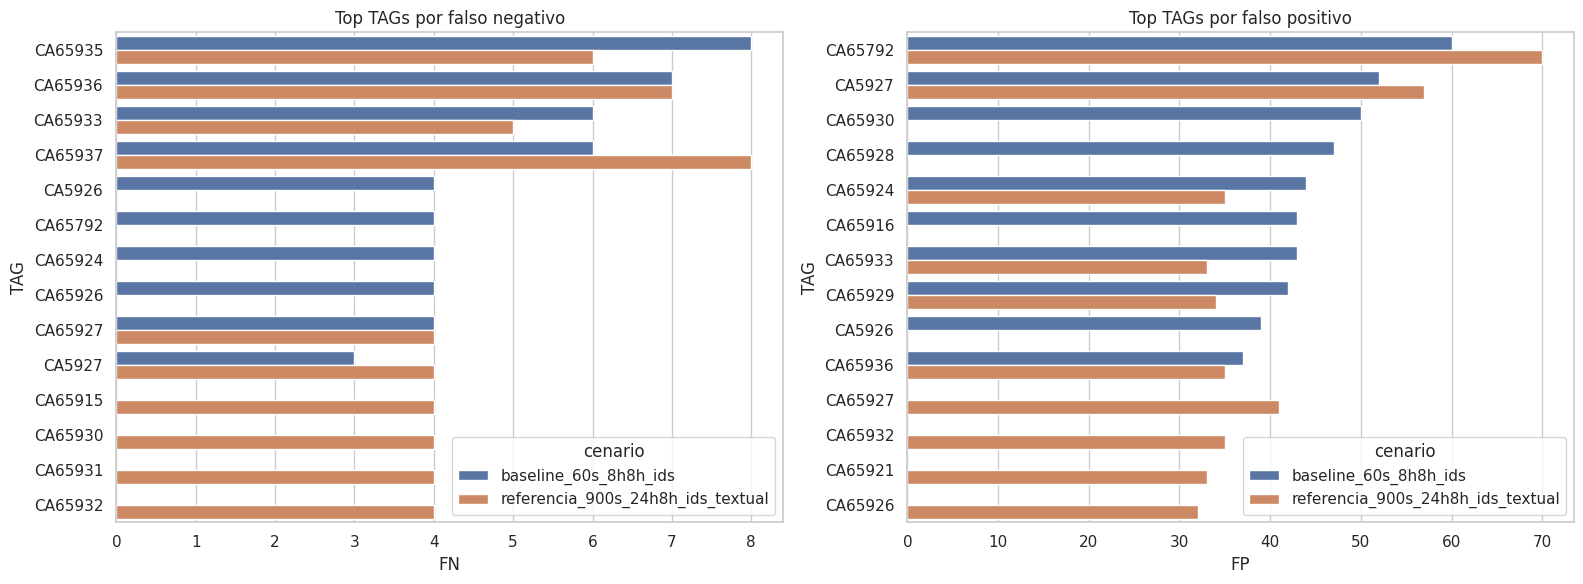

In [8]:
type_audit = summarize_group(predictions, ["cenario", "Tipo"])
display(type_audit.sort_values(["cenario", "FN"], ascending=[True, False]))

tag_audit = summarize_group(predictions, ["cenario", "TAG", "Tipo", "Tag_Frota"])
print("TAGs com mais FN por cenário")
display(tag_audit.sort_values(["cenario", "FN", "positivos_reais"], ascending=[True, False, False]).groupby("cenario").head(15))
print("TAGs com mais FP por cenário")
display(tag_audit.sort_values(["cenario", "FP", "positivos_previstos"], ascending=[True, False, False]).groupby("cenario").head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_fn = tag_audit.sort_values(["cenario", "FN"], ascending=[True, False]).groupby("cenario").head(10)
sns.barplot(data=top_fn, x="FN", y="TAG", hue="cenario", ax=axes[0])
axes[0].set(title="Top TAGs por falso negativo")
top_fp = tag_audit.sort_values(["cenario", "FP"], ascending=[True, False]).groupby("cenario").head(10)
sns.barplot(data=top_fp, x="FP", y="TAG", hue="cenario", ax=axes[1])
axes[1].set(title="Top TAGs por falso positivo")
plt.tight_layout()
plt.show()

## 6. Auditoria temporal e por probabilidade

In [9]:
predictions["data"] = predictions["prediction_time"].dt.date
predictions["semana"] = predictions["prediction_time"].dt.to_period("W").astype(str)
predictions["hora"] = predictions["prediction_time"].dt.hour

daily_audit = summarize_group(predictions, ["cenario", "data"])
week_audit = summarize_group(predictions, ["cenario", "semana"])
hour_audit = summarize_group(predictions, ["cenario", "hora"])
display(daily_audit.sort_values(["cenario", "FN"], ascending=[True, False]).groupby("cenario").head(10))
display(week_audit)
display(hour_audit)

prob_audit = (
    predictions.assign(faixa_probabilidade=pd.cut(predictions["probabilidade"], np.linspace(0, 1, 11), include_lowest=True))
    .groupby(["cenario", "faixa_probabilidade"], observed=False)
    .agg(amostras=("target", "size"), positivos=("target", "sum"), taxa_positiva=("target", "mean"))
    .reset_index()
)
display(prob_audit)

,cenario,data,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
21,baseline_60s_8h8h_ids,2025-06-22,105,15,36,8,28,7,62,0.179412,0.361149,0.222222,0.533333,0.311111,0.142857
23,baseline_60s_8h8h_ids,2025-06-24,105,16,36,9,27,7,62,0.154449,0.306865,0.250000,0.562500,0.303371,0.152381
1,baseline_60s_8h8h_ids,2025-06-02,105,13,30,8,22,5,70,0.156179,0.290321,0.266667,0.615385,0.239130,0.123810
19,baseline_60s_8h8h_ids,2025-06-20,105,7,33,2,31,5,67,0.178428,0.319970,0.060606,0.285714,0.316327,0.066667
25,baseline_60s_8h8h_ids,2025-06-26,105,12,32,8,24,4,69,0.170896,0.295451,0.250000,0.666667,0.258065,0.114286
29,baseline_60s_8h8h_ids,2025-06-30,105,13,32,9,23,4,69,0.185271,0.374258,0.281250,0.692308,0.250000,0.123810
4,baseline_60s_8h8h_ids,2025-06-05,105,11,34,8,26,3,68,0.202467,0.499060,0.235294,0.727273,0.276596,0.104762
8,baseline_60s_8h8h_ids,2025-06-09,105,10,37,7,30,3,65,0.177359,0.357185,0.189189,0.700000,0.315789,0.095238
9,baseline_60s_8h8h_ids,2025-06-10,105,15,33,12,21,3,69,0.177766,0.398906,0.363636,0.800000,0.233333,0.142857
10,baseline_60s_8h8h_ids,2025-06-11,105,7,33,4,29,3,69,0.169521,0.323112,0.121212,0.571429,0.295918,0.066667


,cenario,semana,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
0,baseline_60s_8h8h_ids,2025-05-26/2025-06-01,70,4,25,4,21,0,45,0.173601,0.362897,0.160000,1.000000,0.318182,0.057143
1,baseline_60s_8h8h_ids,2025-06-02/2025-06-08,735,65,230,51,179,14,491,0.185582,0.396838,0.221739,0.784615,0.267164,0.088435
2,baseline_60s_8h8h_ids,2025-06-09/2025-06-15,735,70,252,55,197,15,468,0.188777,0.410453,0.218254,0.785714,0.296241,0.095238
3,baseline_60s_8h8h_ids,2025-06-16/2025-06-22,735,65,252,47,205,18,465,0.175955,0.332882,0.186508,0.723077,0.305970,0.088435
4,baseline_60s_8h8h_ids,2025-06-23/2025-06-29,735,73,238,50,188,23,474,0.172783,0.335783,0.210084,0.684932,0.283988,0.099320
5,baseline_60s_8h8h_ids,2025-06-30/2025-07-06,105,13,32,9,23,4,69,0.185271,0.374258,0.281250,0.692308,0.250000,0.123810
6,referencia_900s_24h8h_ids_textual,2025-06-02/2025-06-08,735,64,212,47,165,17,506,0.160293,0.385335,0.221698,0.734375,0.245902,0.087075
7,referencia_900s_24h8h_ids_textual,2025-06-09/2025-06-15,735,70,226,53,173,17,492,0.166015,0.415856,0.234513,0.757143,0.260150,0.095238
8,referencia_900s_24h8h_ids_textual,2025-06-16/2025-06-22,735,65,233,49,184,16,486,0.158148,0.349314,0.210300,0.753846,0.274627,0.088435
9,referencia_900s_24h8h_ids_textual,2025-06-23/2025-06-29,735,73,204,48,156,25,506,0.149003,0.338563,0.235294,0.657534,0.235650,0.099320


,cenario,hora,amostras,positivos_reais,positivos_previstos,TP,FP,FN,TN,prob_media,prob_p90,precision,recall,taxa_fp,prevalencia
0,baseline_60s_8h8h_ids,0,1015,95,330,70,260,25,660,0.178110,0.350603,0.212121,0.736842,0.282609,0.093596
1,baseline_60s_8h8h_ids,8,1050,98,356,78,278,20,674,0.183660,0.369773,0.219101,0.795918,0.292017,0.093333
2,baseline_60s_8h8h_ids,16,1050,97,343,68,275,29,678,0.180435,0.363966,0.198251,0.701031,0.288562,0.092381
3,referencia_900s_24h8h_ids_textual,0,1015,96,309,68,241,28,678,0.160087,0.366055,0.220065,0.708333,0.262242,0.094581
4,referencia_900s_24h8h_ids_textual,8,1015,96,304,71,233,25,686,0.161230,0.365025,0.233553,0.739583,0.253536,0.094581
5,referencia_900s_24h8h_ids_textual,16,1015,93,305,69,236,24,686,0.156180,0.363993,0.226230,0.741935,0.255965,0.091626


,cenario,faixa_probabilidade,amostras,positivos,taxa_positiva
0,baseline_60s_8h8h_ids,"(-0.001, 0.1]",1058,15,0.014178
1,baseline_60s_8h8h_ids,"(0.1, 0.2]",991,57,0.057518
2,baseline_60s_8h8h_ids,"(0.2, 0.3]",587,73,0.124361
3,baseline_60s_8h8h_ids,"(0.3, 0.4]",226,57,0.252212
4,baseline_60s_8h8h_ids,"(0.4, 0.5]",85,16,0.188235
5,baseline_60s_8h8h_ids,"(0.5, 0.6]",53,15,0.283019
6,baseline_60s_8h8h_ids,"(0.6, 0.7]",63,26,0.412698
7,baseline_60s_8h8h_ids,"(0.7, 0.8]",40,26,0.650000
8,baseline_60s_8h8h_ids,"(0.8, 0.9]",12,5,0.416667
9,baseline_60s_8h8h_ids,"(0.9, 1.0]",0,0,NaN


## 7. Drill down de casos

In [10]:
for cenario in predictions["cenario"].unique():
    part = predictions[predictions["cenario"] == cenario]
    print(f"\n=== {cenario} ===")
    print("FN de maior probabilidade")
    display(part[part["erro"] == "FN"].sort_values("probabilidade", ascending=False).head(20))
    print("FN de menor probabilidade")
    display(part[part["erro"] == "FN"].sort_values("probabilidade", ascending=True).head(20))
    print("FP de maior probabilidade")
    display(part[part["erro"] == "FP"].sort_values("probabilidade", ascending=False).head(20))


=== baseline_60s_8h8h_ids ===
FN de maior probabilidade


,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,target,cenario,probabilidade,predito,erro,data,semana,hora
1743,CA65936,Caminhao,793-D 5S,2025-06-17 08:00:00,2025-06-17 16:00:00,2025-06-18 00:00:00,1,baseline_60s_8h8h_ids,0.203405,0,FN,2025-06-17,2025-06-16/2025-06-22,16
2433,CA65926,Caminhao,793-D 4S,2025-06-24 00:00:00,2025-06-24 08:00:00,2025-06-24 16:00:00,1,baseline_60s_8h8h_ids,0.202828,0,FN,2025-06-24,2025-06-23/2025-06-29,8
220,CA65915,Caminhao,793-D 4S,2025-06-03 00:00:00,2025-06-03 08:00:00,2025-06-03 16:00:00,1,baseline_60s_8h8h_ids,0.199876,0,FN,2025-06-03,2025-06-02/2025-06-08,8
1193,CA65790,Caminhao,793-D 2S,2025-06-12 08:00:00,2025-06-12 16:00:00,2025-06-13 00:00:00,1,baseline_60s_8h8h_ids,0.198445,0,FN,2025-06-12,2025-06-09/2025-06-15,16
2049,CA65927,Caminhao,793-D 5S,2025-06-20 08:00:00,2025-06-20 16:00:00,2025-06-21 00:00:00,1,baseline_60s_8h8h_ids,0.196621,0,FN,2025-06-20,2025-06-16/2025-06-22,16
1218,CA65936,Caminhao,793-D 5S,2025-06-12 08:00:00,2025-06-12 16:00:00,2025-06-13 00:00:00,1,baseline_60s_8h8h_ids,0.196395,0,FN,2025-06-12,2025-06-09/2025-06-15,16
798,CA65936,Caminhao,793-D 5S,2025-06-08 08:00:00,2025-06-08 16:00:00,2025-06-09 00:00:00,1,baseline_60s_8h8h_ids,0.195940,0,FN,2025-06-08,2025-06-02/2025-06-08,16
79,CA65909,Caminhao,793-D 3S,2025-06-01 16:00:00,2025-06-02 00:00:00,2025-06-02 08:00:00,1,baseline_60s_8h8h_ids,0.195816,0,FN,2025-06-02,2025-06-02/2025-06-08,0
110,CA65792,Caminhao,793-D 2S,2025-06-02 00:00:00,2025-06-02 08:00:00,2025-06-02 16:00:00,1,baseline_60s_8h8h_ids,0.194643,0,FN,2025-06-02,2025-06-02/2025-06-08,8
2468,CA65926,Caminhao,793-D 4S,2025-06-24 08:00:00,2025-06-24 16:00:00,2025-06-25 00:00:00,1,baseline_60s_8h8h_ids,0.194402,0,FN,2025-06-24,2025-06-23/2025-06-29,16


FN de menor probabilidade


,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,target,cenario,probabilidade,predito,erro,data,semana,hora
137,PE3797,Escavadeira,LeTourneau L 1850,2025-06-02 00:00:00,2025-06-02 08:00:00,2025-06-02 16:00:00,1,baseline_60s_8h8h_ids,0.002835,0,FN,2025-06-02,2025-06-02/2025-06-08,8
2725,PE3795,Escavadeira,LeTourneau L 1850,2025-06-26 16:00:00,2025-06-27 00:00:00,2025-06-27 08:00:00,1,baseline_60s_8h8h_ids,0.024655,0,FN,2025-06-27,2025-06-23/2025-06-29,0
945,CA5926,Caminhao,793-D 5S,2025-06-10 00:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,1,baseline_60s_8h8h_ids,0.049765,0,FN,2025-06-10,2025-06-09/2025-06-15,8
1114,CA65937,Caminhao,793-D 5S,2025-06-11 08:00:00,2025-06-11 16:00:00,2025-06-12 00:00:00,1,baseline_60s_8h8h_ids,0.050385,0,FN,2025-06-11,2025-06-09/2025-06-15,16
2993,CA65926,Caminhao,793-D 4S,2025-06-29 08:00:00,2025-06-29 16:00:00,2025-06-30 00:00:00,1,baseline_60s_8h8h_ids,0.059390,0,FN,2025-06-29,2025-06-23/2025-06-29,16
379,CA65937,Caminhao,793-D 5S,2025-06-04 08:00:00,2025-06-04 16:00:00,2025-06-05 00:00:00,1,baseline_60s_8h8h_ids,0.064025,0,FN,2025-06-04,2025-06-02/2025-06-08,16
3016,CA65793,Caminhao,793-D 2S,2025-06-29 16:00:00,2025-06-30 00:00:00,2025-06-30 08:00:00,1,baseline_60s_8h8h_ids,0.067147,0,FN,2025-06-30,2025-06-30/2025-07-06,0
158,CA65926,Caminhao,793-D 4S,2025-06-02 08:00:00,2025-06-02 16:00:00,2025-06-03 00:00:00,1,baseline_60s_8h8h_ids,0.071890,0,FN,2025-06-02,2025-06-02/2025-06-08,16
1637,CA65935,Caminhao,793-D 5S,2025-06-16 08:00:00,2025-06-16 16:00:00,2025-06-17 00:00:00,1,baseline_60s_8h8h_ids,0.071890,0,FN,2025-06-16,2025-06-16/2025-06-22,16
762,CA65935,Caminhao,793-D 5S,2025-06-08 00:00:00,2025-06-08 08:00:00,2025-06-08 16:00:00,1,baseline_60s_8h8h_ids,0.073508,0,FN,2025-06-08,2025-06-02/2025-06-08,8


FP de maior probabilidade


...

,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,target,cenario,probabilidade,predito,erro,data,semana,hora
5625,CA65933,Caminhao,793-D 5S,2025-06-24 16:00:00,2025-06-25 16:00:00,2025-06-26 00:00:00,1,referencia_900s_24h8h_ids_textual,0.189368,0,FN,2025-06-25,2025-06-23/2025-06-29,16
5520,CA65933,Caminhao,793-D 5S,2025-06-23 16:00:00,2025-06-24 16:00:00,2025-06-25 00:00:00,1,referencia_900s_24h8h_ids_textual,0.188888,0,FN,2025-06-24,2025-06-23/2025-06-29,16
5757,CA65925,Caminhao,793-D 4S,2025-06-26 00:00:00,2025-06-27 00:00:00,2025-06-27 08:00:00,1,referencia_900s_24h8h_ids_textual,0.187594,0,FN,2025-06-27,2025-06-23/2025-06-29,0
5445,CA65928,Caminhao,793-D 5S,2025-06-23 00:00:00,2025-06-24 00:00:00,2025-06-24 08:00:00,1,referencia_900s_24h8h_ids_textual,0.186741,0,FN,2025-06-24,2025-06-23/2025-06-29,0
4753,CA65936,Caminhao,793-D 5S,2025-06-16 08:00:00,2025-06-17 08:00:00,2025-06-17 16:00:00,1,referencia_900s_24h8h_ids_textual,0.186188,0,FN,2025-06-17,2025-06-16/2025-06-22,8
4928,CA65936,Caminhao,793-D 5S,2025-06-18 00:00:00,2025-06-19 00:00:00,2025-06-19 08:00:00,1,referencia_900s_24h8h_ids_textual,0.185515,0,FN,2025-06-19,2025-06-16/2025-06-22,0
5094,CA65927,Caminhao,793-D 5S,2025-06-19 16:00:00,2025-06-20 16:00:00,2025-06-21 00:00:00,1,referencia_900s_24h8h_ids_textual,0.185393,0,FN,2025-06-20,2025-06-16/2025-06-22,16
3138,CA65931,Caminhao,793-D 5S,2025-06-01 00:00:00,2025-06-02 00:00:00,2025-06-02 08:00:00,1,referencia_900s_24h8h_ids_textual,0.184604,0,FN,2025-06-02,2025-06-02/2025-06-08,0
5694,CA65932,Caminhao,793-D 5S,2025-06-25 08:00:00,2025-06-26 08:00:00,2025-06-26 16:00:00,1,referencia_900s_24h8h_ids_textual,0.183711,0,FN,2025-06-26,2025-06-23/2025-06-29,8
4012,CA65930,Caminhao,793-D 5S,2025-06-09 08:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,1,referencia_900s_24h8h_ids_textual,0.182884,0,FN,2025-06-10,2025-06-09/2025-06-15,8


FN de menor probabilidade


,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,target,cenario,probabilidade,predito,erro,data,semana,hora
5770,PE3795,Escavadeira,LeTourneau L 1850,2025-06-26 00:00:00,2025-06-27 00:00:00,2025-06-27 08:00:00,1,referencia_900s_24h8h_ids_textual,0.000000,0,FN,2025-06-27,2025-06-23/2025-06-29,0
3182,PE3797,Escavadeira,LeTourneau L 1850,2025-06-01 08:00:00,2025-06-02 08:00:00,2025-06-02 16:00:00,1,referencia_900s_24h8h_ids_textual,0.008041,0,FN,2025-06-02,2025-06-02/2025-06-08,8
5864,CA65927,Caminhao,793-D 5S,2025-06-27 00:00:00,2025-06-28 00:00:00,2025-06-28 08:00:00,1,referencia_900s_24h8h_ids_textual,0.044682,0,FN,2025-06-28,2025-06-23/2025-06-29,0
6061,CA65793,Caminhao,793-D 2S,2025-06-29 00:00:00,2025-06-30 00:00:00,2025-06-30 08:00:00,1,referencia_900s_24h8h_ids_textual,0.051178,0,FN,2025-06-30,2025-06-30/2025-07-06,0
3195,CA65915,Caminhao,793-D 4S,2025-06-01 16:00:00,2025-06-02 16:00:00,2025-06-03 00:00:00,1,referencia_900s_24h8h_ids_textual,0.058024,0,FN,2025-06-02,2025-06-02/2025-06-08,16
4077,CA65925,Caminhao,793-D 4S,2025-06-10 00:00:00,2025-06-11 00:00:00,2025-06-11 08:00:00,1,referencia_900s_24h8h_ids_textual,0.065452,0,FN,2025-06-11,2025-06-09/2025-06-15,0
4345,CA65792,Caminhao,793-D 2S,2025-06-12 16:00:00,2025-06-13 16:00:00,2025-06-14 00:00:00,1,referencia_900s_24h8h_ids_textual,0.067299,0,FN,2025-06-13,2025-06-09/2025-06-15,16
3990,CA5926,Caminhao,793-D 5S,2025-06-09 08:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,1,referencia_900s_24h8h_ids_textual,0.074674,0,FN,2025-06-10,2025-06-09/2025-06-15,8
3203,CA65926,Caminhao,793-D 4S,2025-06-01 16:00:00,2025-06-02 16:00:00,2025-06-03 00:00:00,1,referencia_900s_24h8h_ids_textual,0.077604,0,FN,2025-06-02,2025-06-02/2025-06-08,16
5662,CA65935,Caminhao,793-D 5S,2025-06-25 00:00:00,2025-06-26 00:00:00,2025-06-26 08:00:00,1,referencia_900s_24h8h_ids_textual,0.078474,0,FN,2025-06-26,2025-06-23/2025-06-29,0


FP de maior probabilidade


,TAG,Tipo,Tag_Frota,feature_start,prediction_time,target_end,target,cenario,probabilidade,predito,erro,data,semana,hora
4423,CA65921,Caminhao,793-D 4S,2025-06-13 08:00:00,2025-06-14 08:00:00,2025-06-14 16:00:00,0,referencia_900s_24h8h_ids_textual,0.783283,1,FP,2025-06-14,2025-06-09/2025-06-15,8
6091,CA5927,Caminhao,793-D 5S,2025-06-29 08:00:00,2025-06-30 08:00:00,2025-06-30 16:00:00,0,referencia_900s_24h8h_ids_textual,0.771417,1,FP,2025-06-30,2025-06-30/2025-07-06,8
4568,CA65926,Caminhao,793-D 4S,2025-06-14 16:00:00,2025-06-15 16:00:00,2025-06-16 00:00:00,0,referencia_900s_24h8h_ids_textual,0.760531,1,FP,2025-06-15,2025-06-09/2025-06-15,16
4183,CA65926,Caminhao,793-D 4S,2025-06-11 00:00:00,2025-06-12 00:00:00,2025-06-12 08:00:00,0,referencia_900s_24h8h_ids_textual,0.752694,1,FP,2025-06-12,2025-06-09/2025-06-15,0
4014,CA65932,Caminhao,793-D 5S,2025-06-09 08:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,0,referencia_900s_24h8h_ids_textual,0.743357,1,FP,2025-06-10,2025-06-09/2025-06-15,8
4084,CA65932,Caminhao,793-D 5S,2025-06-10 00:00:00,2025-06-11 00:00:00,2025-06-11 08:00:00,0,referencia_900s_24h8h_ids_textual,0.716259,1,FP,2025-06-11,2025-06-09/2025-06-15,0
3405,CA65915,Caminhao,793-D 4S,2025-06-03 16:00:00,2025-06-04 16:00:00,2025-06-05 00:00:00,0,referencia_900s_24h8h_ids_textual,0.702372,1,FP,2025-06-04,2025-06-02/2025-06-08,16
4003,CA65921,Caminhao,793-D 4S,2025-06-09 08:00:00,2025-06-10 08:00:00,2025-06-10 16:00:00,0,referencia_900s_24h8h_ids_textual,0.688405,1,FP,2025-06-10,2025-06-09/2025-06-15,8
3562,CA65935,Caminhao,793-D 5S,2025-06-05 00:00:00,2025-06-06 00:00:00,2025-06-06 08:00:00,0,referencia_900s_24h8h_ids_textual,0.678637,1,FP,2025-06-06,2025-06-02/2025-06-08,0
3979,CA65932,Caminhao,793-D 5S,2025-06-09 00:00:00,2025-06-10 00:00:00,2025-06-10 08:00:00,0,referencia_900s_24h8h_ids_textual,0.671479,1,FP,2025-06-10,2025-06-09/2025-06-15,0


## 8. Leitura auditada

Critérios:

- se a nova referência reduz FP e mantém recall, ela substitui o baseline histórico como base de
  desenvolvimento;
- se melhora apenas por mudar prevalência ou target, registrar essa diferença explicitamente;
- escavadeiras continuam exigindo leitura separada por escassez de positivos;
- próximos experimentos devem partir da nova referência apenas se os erros residuais forem
  compreensíveis e documentados.